In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 5 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# EN: A safe "no-op" layer for Method 0 (no augmentation).
# CN: 用于 Method 0 的“空增强层”，避免 Sequential 没有 layer 报错
# -----------------------------
class IdentityLayer(tf.keras.layers.Layer):
    def call(self, x, training=None):
        return x

# -----------------------------
# EN: Choose TensorFlow augmentation by method_id (0~4).
# CN: 根据 method_id 选择 TensorFlow 增强策略（0~4），二分法之外你这里是“5种方案对比”
# -----------------------------
def get_augmentation(method_id: int, is_rgb: bool) -> tf.keras.Model:
    """
    Method 0: No augmentation (Identity).
    Method 1: Rotation.
    Method 2: Translation.
    Method 3: Zoom.
    Method 4: Rotation + Translation + Zoom (+ Contrast for RGB).
    """
    if method_id == 0:
        # EN: No augmentation.
        # CN: 不增强，返回一个恒等映射层
        return tf.keras.Sequential([IdentityLayer()], name="aug_none")

    layers = []
    if method_id == 1:
        layers.append(tf.keras.layers.RandomRotation(0.08))
    elif method_id == 2:
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
    elif method_id == 3:
        layers.append(tf.keras.layers.RandomZoom(0.10))
    elif method_id == 4:
        layers.append(tf.keras.layers.RandomRotation(0.08))
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
        layers.append(tf.keras.layers.RandomZoom(0.10))
        if is_rgb:
            layers.append(tf.keras.layers.RandomContrast(0.10))

    return tf.keras.Sequential(layers, name=f"aug_{method_id}")

# -----------------------------
# EN: Simple CNN baseline (same architecture across methods).
# CN: 统一 CNN 模型结构（保证对比公平）
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# EN: Train one method and return history + final train/val accuracy.
# CN: 训练单个增强方案，返回 history + 最终训练/验证准确率（便于判断过拟合）
# -----------------------------
def run_one_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    aug = get_augmentation(method_id, is_rgb)

    # EN: Build tf.data pipeline.
    # CN: 用 tf.data 加速，并确保“只在训练集做增强”
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    # EN: Apply augmentation only for training.
    # CN: 仅训练集增强；验证集不做增强（评估公平）
    def train_map(x, y):
        x = aug(x, training=True)
        return x, y

    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    model = build_cnn(input_shape, num_classes)
    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc

# -----------------------------
# EN: Plot accuracy + loss curves.
# CN: 画训练/验证的 accuracy 与 loss 曲线
# -----------------------------
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

##  SVHN

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Size...:   4%|██▎                                                               | 53/1501 [00:10<03:35,  6.72 MiB/s]


Dl Completed...:   0%|                                                                         | 0/3 [00:13<?, ? url/s]


Dl Completed...:   0%|                                                                         | 0/3 [00:15<?, ? url/s]


Dl Completed...:  33%|█████████████████████▋                                           | 1/3 [00:20<00:34, 17.04s/ url]


...

Generating splits...:   0%|                                                                 | 0/3 [00:00<?, ? splits/s]
Generating train examples...: 0 examples [00:00, ? examples/s]
Generating train examples...: 1 examples [00:01,  1.10s/ examples]
Generating train examples...: 3865 examples [00:02, 2182.95 examples/s]
Generating train examples...: 7618 examples [00:03, 2882.93 examples/s]
Generating train examples...: 11418 examples [00:04, 3239.31 examples/s]
Generating train examples...: 15319 examples [00:05, 3475.52 examples/s]
Generating train examples...: 19240 examples [00:06, 3625.49 examples/s]
Generating train examples...: 23008 examples [00:07, 3671.49 examples/s]
Generating train examples...: 26726 examples [00:08, 3686.09 examples/s]
Generating train examples...: 30631 examples [00:09, 3753.91 examples/s]
Generating train examples...: 34393 examples [00:10, 3756.29 examples/s]
Generating train examples...: 38191 examples [00:11, 3768.29 examples/s]
Generating train examp

                                                                       
Shuffling C:\Users\JimmyWu\tensorflow_datasets\svhn_cropped\incomplete.T3L4V8_3.1.0\svhn_cropped-test.tfrecord*...:   0
Generating splits...:  67%|██████████████████████████████████████                   | 2/3 [00:30<00:13, 13.86s/ splits]
Generating extra examples...: 0 examples [00:00, ? examples/s]
Generating extra examples...: 1 examples [00:07,  7.22s/ examples]
Generating extra examples...: 3924 examples [00:08, 647.77 examples/s]
Generating extra examples...: 7743 examples [00:09, 1252.95 examples/s]
Generating extra examples...: 11471 examples [00:10, 1782.78 examples/s]
Generating extra examples...: 15393 examples [00:11, 2283.52 examples/s]
Generating extra examples...: 19254 examples [00:12, 2678.49 examples/s]
Generating extra examples...: 22963 examples [00:13, 2949.61 examples/s]
Generating extra examples...: 26736 examples [00:14, 3174.54 examples/s]
Generating extra examples...: 30429 examples [00:1

Generating extra examples...: 397302 examples [01:48, 3908.96 examples/s]
Generating extra examples...: 401254 examples [01:49, 3921.39 examples/s]
Generating extra examples...: 405177 examples [01:50, 3891.79 examples/s]
Generating extra examples...: 409070 examples [01:51, 3870.80 examples/s]
Generating extra examples...: 412942 examples [01:52, 3848.31 examples/s]
Generating extra examples...: 416809 examples [01:53, 3852.76 examples/s]
Generating extra examples...: 420663 examples [01:55, 3820.27 examples/s]
Generating extra examples...: 424509 examples [01:56, 3826.97 examples/s]
Generating extra examples...: 428377 examples [01:57, 3838.99 examples/s]
Generating extra examples...: 432240 examples [01:58, 3845.48 examples/s]
Generating extra examples...: 436086 examples [01:59, 3827.32 examples/s]
Generating extra examples...: 439961 examples [02:00, 3840.56 examples/s]
Generating extra examples...: 443802 examples [02:01, 3821.22 examples/s]
Generating extra examples...: 447624 e

Dataset svhn_cropped downloaded and prepared to C:\Users\JimmyWu\tensorflow_datasets\svhn_cropped\3.1.0. Subsequent calls will reuse this data.

SVHN - Method 0



Epoch 1/10
1242/1242 - 9s - 7ms/step - accuracy: 0.7301 - loss: 0.8869 - val_accuracy: 0.8430 - val_loss: 0.5745
Epoch 2/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8662 - loss: 0.4823 - val_accuracy: 0.8670 - val_loss: 0.4781
Epoch 3/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8849 - loss: 0.4065 - val_accuracy: 0.8855 - val_loss: 0.4136
Epoch 4/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8958 - loss: 0.3586 - val_accuracy: 0.8835 - val_loss: 0.4099
Epoch 5/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9058 - loss: 0.3260 - val_accuracy: 0.8846 - val_loss: 0.4028
Epoch 6/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9138 - loss: 0.2993 - val_accuracy: 0.8930 - val_loss: 0.3892
Epoch 7/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9205 - loss: 0.2748 - val_accuracy: 0.8950 - val_loss: 0.3746
Epoch 8/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9272 - loss: 0.2498 - val_accuracy: 0.8961 - val_loss: 0.3771
Epoch 9/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9324 - loss: 0.2312 - val_accuracy: 0.8987 - 

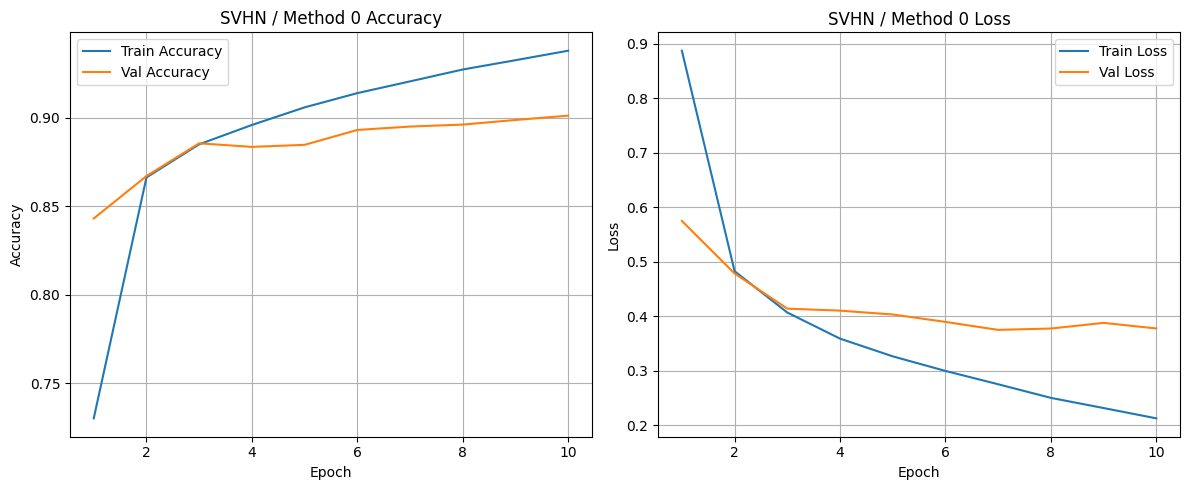


SVHN - Method 1
Epoch 1/10
1242/1242 - 8s - 7ms/step - accuracy: 0.6265 - loss: 1.1631 - val_accuracy: 0.8192 - val_loss: 0.6549
Epoch 2/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8041 - loss: 0.6659 - val_accuracy: 0.8437 - val_loss: 0.5469
Epoch 3/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8348 - loss: 0.5590 - val_accuracy: 0.8576 - val_loss: 0.4839
Epoch 4/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8509 - loss: 0.4988 - val_accuracy: 0.8663 - val_loss: 0.4609
Epoch 5/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8624 - loss: 0.4594 - val_accuracy: 0.8718 - val_loss: 0.4403
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8716 - loss: 0.4342 - val_accuracy: 0.8784 - val_loss: 0.4152
Epoch 7/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8780 - loss: 0.4109 - val_accuracy: 0.8779 - val_loss: 0.4143
Epoch 8/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8842 - loss: 0.3898 - val_accuracy: 0.8835 - val_loss: 0.3966
Epoch 9/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8883 - loss: 0.3742 - val_ac

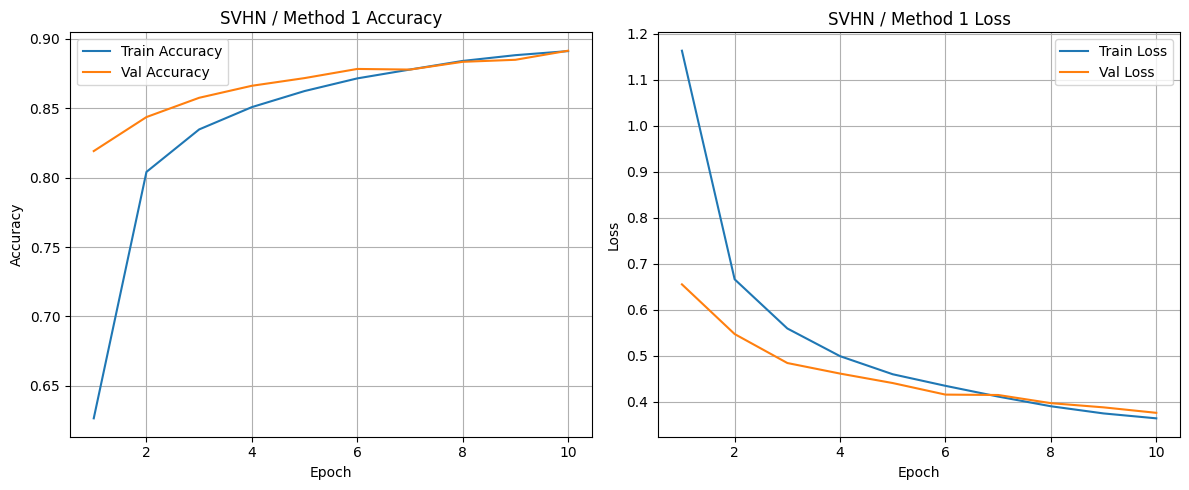


SVHN - Method 2
Epoch 1/10
1242/1242 - 9s - 7ms/step - accuracy: 0.6347 - loss: 1.1502 - val_accuracy: 0.8309 - val_loss: 0.6050
Epoch 2/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8071 - loss: 0.6722 - val_accuracy: 0.8552 - val_loss: 0.5140
Epoch 3/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8352 - loss: 0.5677 - val_accuracy: 0.8744 - val_loss: 0.4382
Epoch 4/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8539 - loss: 0.4996 - val_accuracy: 0.8843 - val_loss: 0.4057
Epoch 5/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8643 - loss: 0.4572 - val_accuracy: 0.8859 - val_loss: 0.3963
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8735 - loss: 0.4266 - val_accuracy: 0.9018 - val_loss: 0.3486
Epoch 7/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8808 - loss: 0.4012 - val_accuracy: 0.9034 - val_loss: 0.3473
Epoch 8/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8893 - loss: 0.3781 - val_accuracy: 0.9060 - val_loss: 0.3236
Epoch 9/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8930 - loss: 0.3640 - val_ac

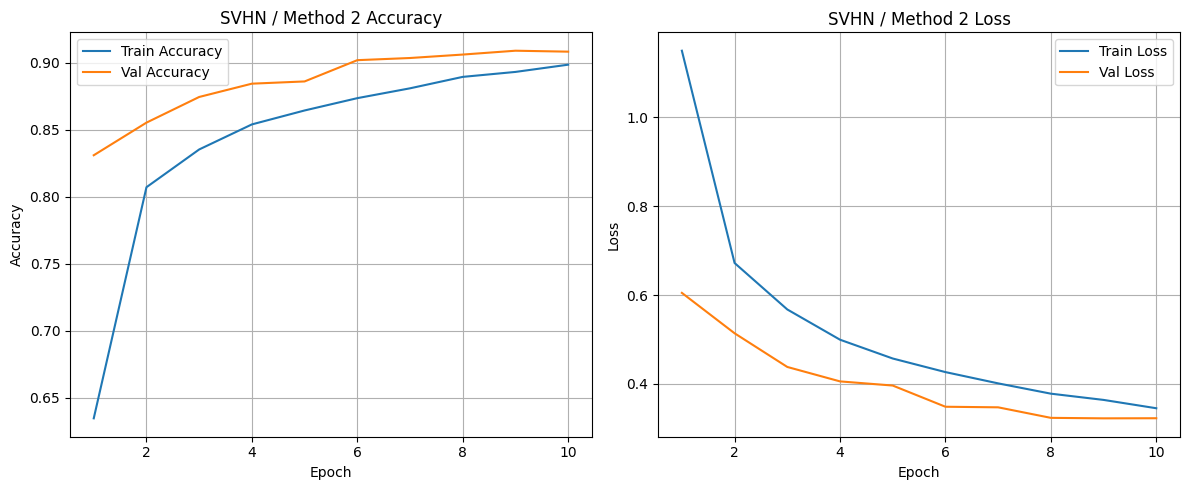


SVHN - Method 3
Epoch 1/10
1242/1242 - 9s - 7ms/step - accuracy: 0.7146 - loss: 0.9314 - val_accuracy: 0.8407 - val_loss: 0.5868
Epoch 2/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8557 - loss: 0.5215 - val_accuracy: 0.8637 - val_loss: 0.4914
Epoch 3/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8753 - loss: 0.4388 - val_accuracy: 0.8790 - val_loss: 0.4270
Epoch 4/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8892 - loss: 0.3854 - val_accuracy: 0.8826 - val_loss: 0.4084
Epoch 5/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8992 - loss: 0.3485 - val_accuracy: 0.8906 - val_loss: 0.3816
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9063 - loss: 0.3201 - val_accuracy: 0.8943 - val_loss: 0.3779
Epoch 7/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9136 - loss: 0.2956 - val_accuracy: 0.8970 - val_loss: 0.3626
Epoch 8/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9204 - loss: 0.2737 - val_accuracy: 0.8943 - val_loss: 0.3734
Epoch 9/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9247 - loss: 0.2568 - val_ac

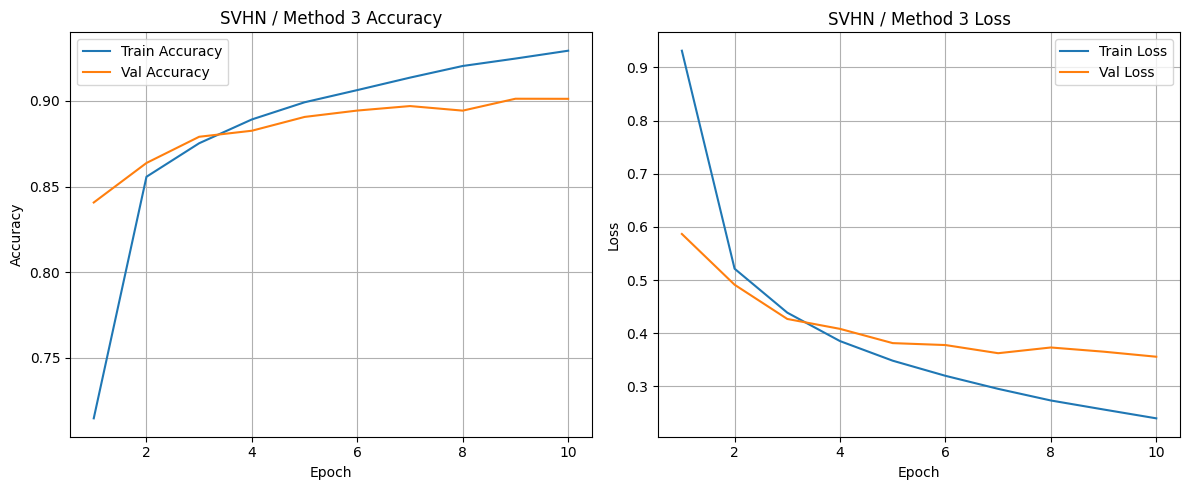


SVHN - Method 4
Epoch 1/10
1242/1242 - 9s - 7ms/step - accuracy: 0.5278 - loss: 1.4364 - val_accuracy: 0.8045 - val_loss: 0.7189
Epoch 2/10
1242/1242 - 8s - 7ms/step - accuracy: 0.7216 - loss: 0.9116 - val_accuracy: 0.8308 - val_loss: 0.5957
Epoch 3/10
1242/1242 - 9s - 7ms/step - accuracy: 0.7635 - loss: 0.7713 - val_accuracy: 0.8474 - val_loss: 0.5124
Epoch 4/10
1242/1242 - 9s - 7ms/step - accuracy: 0.7871 - loss: 0.6933 - val_accuracy: 0.8584 - val_loss: 0.4956
Epoch 5/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8071 - loss: 0.6306 - val_accuracy: 0.8572 - val_loss: 0.4795
Epoch 6/10
1242/1242 - 9s - 7ms/step - accuracy: 0.8197 - loss: 0.5876 - val_accuracy: 0.8738 - val_loss: 0.4244
Epoch 7/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8295 - loss: 0.5576 - val_accuracy: 0.8828 - val_loss: 0.4021
Epoch 8/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8379 - loss: 0.5363 - val_accuracy: 0.8810 - val_loss: 0.4042
Epoch 9/10
1242/1242 - 9s - 7ms/step - accuracy: 0.8421 - loss: 0.5189 - val_ac

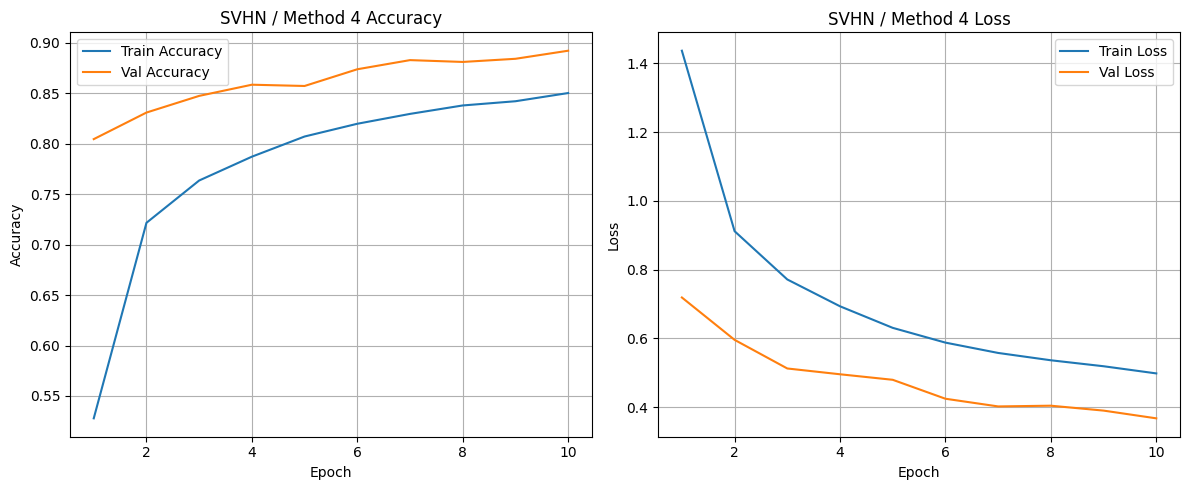


Final accuracy summary (SVHN):
Method 0: train_acc=0.9378, val_acc=0.9011
Method 1: train_acc=0.8913, val_acc=0.8915
Method 2: train_acc=0.8984, val_acc=0.9081
Method 3: train_acc=0.9293, val_acc=0.9012
Method 4: train_acc=0.8502, val_acc=0.8921


In [3]:
# EN: Load SVHN (cropped) from TFDS and concatenate train/test.
# CN: 从 TFDS 加载 SVHN（cropped）并合并 train/test
ds_train = tfds.load("svhn_cropped", split="train", as_supervised=True)
ds_test  = tfds.load("svhn_cropped", split="test",  as_supervised=True)

# EN: Convert tf.data to numpy arrays (simple for coursework).
# CN: 为了作业方便，转成 numpy；数据较大时更推荐直接 tf.data pipeline
def ds_to_numpy(ds):
    images, labels = [], []
    for x, y in tfds.as_numpy(ds):
        images.append(x)
        labels.append(y)
    return np.stack(images), np.array(labels)

X0, y0 = ds_to_numpy(ds_train)
X1, y1 = ds_to_numpy(ds_test)

X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# EN: Normalize to [0,1].
# CN: 归一化到 [0,1]
X = X.astype("float32") / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (32, 32, 3)
num_classes = 10
is_rgb = True

results = {}

for method_id in range(5):
    print("\n==============================")
    print(f"SVHN - Method {method_id}")
    print("==============================")

    history, train_acc, val_acc = run_one_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape, num_classes=num_classes,
        method_id=method_id, is_rgb=is_rgb
    )
    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"SVHN / Method {method_id}")

print("\nFinal accuracy summary (SVHN):")
for k, (ta, va) in results.items():
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")


## Conclusion for SVHN (TensorFlow Data Augmentation) 